# Top Model Decision Tree


### ⚠️ Google Colab Only Notebook

This notebook is designed to run in **Google Colab**. To start using this notebook, clone this GitHub repo in Colab:
```
!git clone https://github.com/Lynnicia/CryoEM_ultrastructures_top_model_decision_tree/tree/main.git
```
It requires:
- GPU runtime (CUDA) for speed tests
- Linux environment
- Colab-specific install steps (e.g., `!pip install`, `!git clone`, `from google.colab.patches import cv2_imshow`)

❌ Running locally (especially on Windows) may fail due to:
- Detectron2 installation issues
- CUDA/toolchain mismatches
- Missing compiled operators

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Lynnicia/CryoEM_ultrastructures_top_model_decision_tree/tree/main)
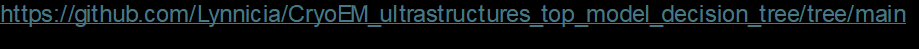
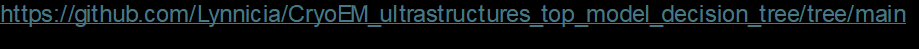
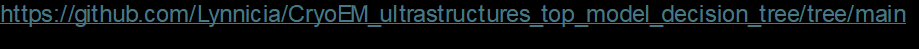
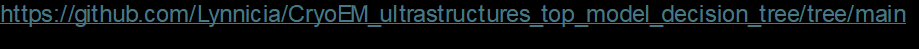

 ```
          @@@@@@@@@@@@@@@@@@@@@
       @@@@@@@@@@@@@@@@@@@@@@@@@@@
    @@                             @@
  @@    @@@@@  @@@@@  @@@@@  @@@     @@
 @@    @       @      @      @  @     @@
 @@    @@@@@   @@@    @@@    @   @    @@
 @@         @  @      @      @   @    @@
  @@   @@@@@   @@@@@  @@@@@  @@@@    @@
   @@                              @@
      @@@@@@@@@@@@@@@@@@@@@@@@@@@@
         @@@@@@@@@@@@@@@@@@@@@@
```
##### Load in model architectures:

Fine-tuned pre-trained models to load: YOLOv11, YOLO26, U-Net, Detectron2 and SAM3
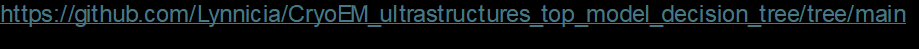

In [8]:
%run seed/model_arch.ipynb

Loading YOLOv11 and YOLO26...
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl (158 kB)
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 5.1
    Uninstalling PyYAML-5.1:
      Successfully uninstalled PyYAML-5.1
✓ YOLOv11 and YOLO26 model architectures loaded
Loading U-Net...



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...

torch:  2.11 ; cuda:  cpu


'nvcc' is not recognized as an internal or external command,
operable program or batch file.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'detectron2.utils'

ModuleNotFoundError: No module named 'detectron2.utils'

##### Load in LD and ULD Model Seeds:

In [7]:
from seed import LDmodels, ULDmodels
from seed.LDmodels import MODEL_MAP as LD_MODEL_MAP
from seed.ULDmodels import MODEL_MAP as ULD_MODEL_MAP

MODEL_MAP = {
    **LD_MODEL_MAP,
    **ULD_MODEL_MAP,
}

print(MODEL_MAP)

{('LD', 640): <function model_LD_640 at 0x0000015755C665C0>, ('LD', 1024): <function model_LD_1024 at 0x0000015755CF49A0>, ('ULD', 640): <function model_ULD_640 at 0x0000015755C66AC0>, ('ULD', 1024): <function model_ULD_1024 at 0x0000015755CF4AE0>}


##### Load in test images:

### Step 1: What image scale is needed?

##### What model electron dose (med) do you want to use?

LD --> LD model sets

ULD --> ULD model sets

both --> LD and ULS model sets

In [ ]:
med = LD

##### What test image electron dose (ted) do you want to use?

LD --> LD model sets

ULD --> ULD model sets

both --> LD and ULS model sets

In [ ]:
ted = LD

### Step 2: What mask count is needed?

##### How many bacteria are in your test images? Manually count your test images and input the count below:

In [ ]:
manualcount = 20

##### Masks are then updated to output predicted count

In [ ]:
# define function
maskcount()

### Step 3: Which classes are needed?

IM, OM or all?

List TOP 5 models

#If there is a tie on mAP@0.5 or AUPRC, then rank based on the top F1 based ONLY on the tied scores

##### Step 3.1: Load in all models based on selected class

Step 3.2: Run validation metrics on the loaded models based on the valid_model used in the coresponding code (unique for each code set:

In [ ]:
def yolo_metrics(yolo)
"""
Yolo code block for Yolov11 and yolo26
load in ultralytics if needed (likely redundant)
valid = (look for original code in the yolo database)
"""

def unet_metrics(yolo)
"""
U-net code block
valid = [valid block depending on step 1]
"""

#If ultr